# 05 — Moisture, saturation, and a CCN-motivated hypothesis

## Scientific rationale: smoke as cloud condensation nuclei

Wildfire smoke adds **aerosol particles** that can act as **cloud condensation nuclei (CCN)**. In the atmosphere that often means **more cloud droplets** (at a given liquid water path), which can alter **radiation**, **evaporation**, and **boundary-layer humidity**. Those are **real physical pathways**, but at a **single ASOS station** (KEUG) cloud droplet number **is not observed** directly. Hourly data permit testing of **moisture and saturation proxies** that sometimes move in directions **consistent with** (or **inconsistent with**) a CCN story — always **observational**.

## Moisture and saturation outcomes

1. **`humidity`** — relative humidity (%).  
2. **`dewpoint_depression_f`** — \(T - T_d\) in °F. **Smaller** depression means air is **closer to saturation** (fog/stratus more plausible). CCN-rich layers do not *guarantee* lower depression, but sustained **moistening / nearer saturation** in the **hours after** smoke is one **weak** observable signature.  
3. **`visibility_km`** (optional) — **reduced** visibility can mean **aerosol** (smoke) or **hydrometeors** (fog, rain). It is **ambiguous**; interpret alongside RH and \(T-T_d\).

## Identification strategy

- **Exposure:** lagged LRAPA-corrected PM2.5 (`pm2.5_lrapa_lag_6h` by default — set `PM_LAG_COL` to `pm2.5_lrapa_lag_3h` or `pm2.5_lrapa_lag_12h` for sensitivity checks).  
- **Controls (same hour as outcome):** `temperature_f`, `pressure_hpa`, `wind_speed_mph`, `hour`, `dayofyear` — so we ask: *after conditioning on broad thermodynamic and circulation state and diurnal/seasonal cycle, does prior smoke still line up with moisture?*  
- **Evaluation:** **`TimeSeriesSplit`** cross-validation (time-series cross-validation (`TimeSeriesSplit`) — more stable than a single 80/20 cut).  
- **Nested comparison:** **M0** = controls only vs **M1** = controls + PM2.5 lag. If M1 **never** beats M0 on average test RMSE, that indicates **this signal is not robust** in the KEUG hourly sample (still not proof of no physical effect).

**Libraries:** `pandas`, `numpy`, `matplotlib`, `sklearn` (already in `requirements.txt`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## 1. Load panel and build moisture outcomes

In [2]:
df = pd.read_csv('../data/processed/analysis_data.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

df['dewpoint_depression_f'] = df['temperature_f'] - df['dewpoint_f']

PM_LAG_COL = 'pm2.5_lrapa_lag_6h'
CONTROL_COLS = [
    'temperature_f',
    'pressure_hpa',
    'wind_speed_mph',
    'hour',
    'dayofyear',
]

OUTCOMES = {
    'humidity': 'Relative humidity (%)',
    'dewpoint_depression_f': 'Dewpoint depression T − Td (°F)',
}
if 'visibility_km' in df.columns and df['visibility_km'].notna().sum() > 200:
    OUTCOMES['visibility_km'] = 'Visibility (km) — aerosol and/or hydrometeors'

need = [PM_LAG_COL] + CONTROL_COLS + list(OUTCOMES.keys())
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f'Missing columns: {missing} — regenerate the cleaned dataset')

work = df[['timestamp'] + need].dropna().copy()
print(f'Rows used (complete cases): {len(work):,}')
print(f'Exposure: {PM_LAG_COL}')
work[list(OUTCOMES.keys())].describe().round(2)


Rows used (complete cases): 3,224
Exposure: pm2.5_lrapa_lag_6h


,humidity,dewpoint_depression_f,visibility_km
count,3224.00,3224.00,3224.00
mean,64.63,14.37,14.24
std,21.55,11.57,4.57
min,13.26,0.00,0.00
25%,46.70,5.00,16.09
50%,67.86,11.00,16.09
75%,83.29,22.00,16.09
max,100.00,54.05,16.09


## 2. Exploratory: moisture vs lagged PM2.5 (raw and within approximate T bins)

RH is strongly tied to **temperature**; binning by **rounded °F** is a coarse way to show whether any PM–moisture tilt persists when **T is roughly similar** (not a substitute for regression controls).

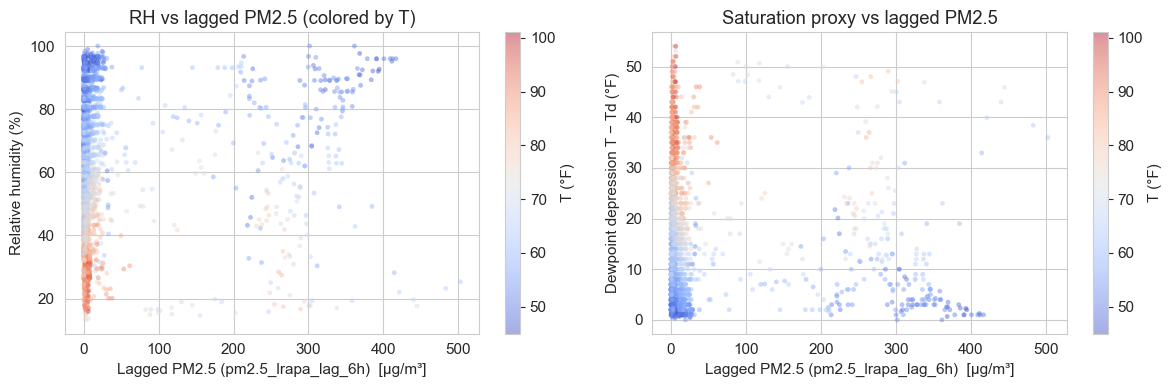

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
sc = ax.scatter(
    work[PM_LAG_COL],
    work['humidity'],
    c=work['temperature_f'],
    cmap='coolwarm',
    s=12,
    alpha=0.45,
    edgecolors='none',
)
plt.colorbar(sc, ax=ax, label='T (°F)')
ax.set_xlabel(f'Lagged PM2.5 ({PM_LAG_COL})  [µg/m³]')
ax.set_ylabel('Relative humidity (%)')
ax.set_title('RH vs lagged PM2.5 (colored by T)')

ax = axes[1]
sc = ax.scatter(
    work[PM_LAG_COL],
    work['dewpoint_depression_f'],
    c=work['temperature_f'],
    cmap='coolwarm',
    s=12,
    alpha=0.45,
    edgecolors='none',
)
plt.colorbar(sc, ax=ax, label='T (°F)')
ax.set_xlabel(f'Lagged PM2.5 ({PM_LAG_COL})  [µg/m³]')
ax.set_ylabel('Dewpoint depression T − Td (°F)')
ax.set_title('Saturation proxy vs lagged PM2.5')

plt.tight_layout()
plt.savefig('../data/processed/fig_moisture_vs_lagged_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

## 2b. RH residual (linear in **T** only), then CV on that residual

**Goal:** remove the **strong** `RH ↔ temperature` link so the outcome is closer to “**moisture given T**.”

**Procedure:**
1. On each **TimeSeriesSplit** fold, fit `humidity ~ 1 + temperature_f` using **training rows only**.
2. Form **residuals** on train and test with **that fold’s** coefficients (test never sees its own T–RH fit).
3. Regress residuals on **M0:** `pressure_hpa`, `wind_speed_mph`, `hour`, `dayofyear` (all scaled) vs **M1:** same + **lagged PM2.5** (raw µg/m³).

If M1 **lowers** mean test RMSE here, lagged PM2.5 helps explain **RH not already captured by T and the other controls**.

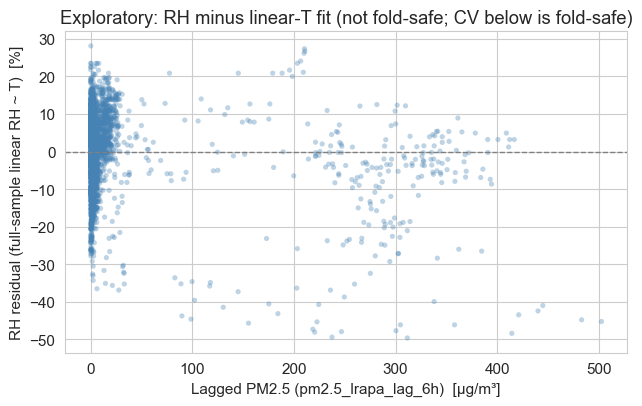

Outcome: RH residual (linear T removed, fold-wise — no leakage)
               train_rmse  test_rmse  train_r2  test_r2
model                                                  
M0_controls       10.5183    11.1573    0.0379  -0.7894
M1_ctrl+PMlag     10.1526    13.0480    0.1016  -1.1816

Mean test RMSE(M1) - Mean test RMSE(M0) = +1.8907  (negative => M1 better)

Exploratory full-sample β_PM on RH residual (after global linear T): -0.032519 per µg/m³


In [ ]:
from sklearn.linear_model import LinearRegression

alphas = np.logspace(-2, 4, 40)  # same grid as Section 3; required if Section 2b is executed first

CONTROL_COLS_NO_T = ['pressure_hpa', 'wind_speed_mph', 'hour', 'dayofyear']

# --- EDA only: global linear RH ~ T (full sample) for a quick scatter ---
lr_eda = LinearRegression().fit(work[['temperature_f']], work['humidity'])
work['rh_resid_eda'] = work['humidity'] - lr_eda.predict(work[['temperature_f']])

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(work[PM_LAG_COL], work['rh_resid_eda'], s=14, alpha=0.35, color='steelblue', edgecolors='none')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel(f'Lagged PM2.5 ({PM_LAG_COL})  [µg/m³]')
ax.set_ylabel('RH residual (full-sample linear RH ~ T)  [%]')
ax.set_title('Exploratory: RH minus linear-T fit (not fold-safe; CV below is fold-safe)')
plt.tight_layout()
plt.savefig('../data/processed/fig_rh_residual_vs_lagged_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Fold-wise residual + Ridge CV (no leakage) ---
N_PM = 1
N_CTRL_NT = len(CONTROL_COLS_NO_T)
ctrl_nt_idx = list(range(N_PM, N_PM + N_CTRL_NT))

pre_m1_nt = ColumnTransformer(
    [
        ('pm_pass', 'passthrough', [0]),
        ('ctrl_scale', StandardScaler(), ctrl_nt_idx),
    ]
)
pre_m0_nt = ColumnTransformer(
    [('ctrl_scale', StandardScaler(), list(range(N_CTRL_NT)))]
)


def cv_ridge_on_rh_residual_foldwise(
    X_pm, X_ctrl_no_t, T, RH, n_splits=5
):
    """Remove linear RH~T per fold (train-only fit), then Ridge M0/M1 on residual."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (tr, te) in enumerate(tscv.split(T)):
        lr = LinearRegression()
        lr.fit(T[tr].reshape(-1, 1), RH[tr])
        res_tr = RH[tr] - lr.predict(T[tr].reshape(-1, 1))
        res_te = RH[te] - lr.predict(T[te].reshape(-1, 1))

        X0_tr = X_ctrl_no_t[tr]
        X0_te = X_ctrl_no_t[te]
        X1_tr = np.column_stack([X_pm[tr], X_ctrl_no_t[tr]])
        X1_te = np.column_stack([X_pm[te], X_ctrl_no_t[te]])

        m0 = Pipeline(
            [('prep', pre_m0_nt), ('ridge', RidgeCV(alphas=alphas, cv=3))]
        )
        m1 = Pipeline(
            [('prep', pre_m1_nt), ('ridge', RidgeCV(alphas=alphas, cv=3))]
        )

        m0.fit(X0_tr, res_tr)
        m1.fit(X1_tr, res_tr)

        for name, model, Xtr, Xev, ytr, yev in [
            ('M0_controls', m0, X0_tr, X0_te, res_tr, res_te),
            ('M1_ctrl+PMlag', m1, X1_tr, X1_te, res_tr, res_te),
        ]:
            pred_tr = model.predict(Xtr)
            pred_te = model.predict(Xev)
            rows.append(
                {
                    'fold': fold,
                    'model': name,
                    'train_rmse': np.sqrt(mean_squared_error(ytr, pred_tr)),
                    'test_rmse': np.sqrt(mean_squared_error(yev, pred_te)),
                    'train_r2': r2_score(ytr, pred_tr),
                    'test_r2': r2_score(yev, pred_te),
                }
            )
    return pd.DataFrame(rows)


X_pm2 = work[PM_LAG_COL].values.reshape(-1, 1)
X_ctrl_nt = work[CONTROL_COLS_NO_T].values
T_arr = work['temperature_f'].values
RH_arr = work['humidity'].values

res_cv = cv_ridge_on_rh_residual_foldwise(X_pm2, X_ctrl_nt, T_arr, RH_arr, n_splits=5)
agg_r = res_cv.groupby('model')[['train_rmse', 'test_rmse', 'train_r2', 'test_r2']].mean()
d_r = agg_r.loc['M1_ctrl+PMlag', 'test_rmse'] - agg_r.loc['M0_controls', 'test_rmse']

print('=' * 60)
print('Outcome: RH residual (linear T removed, fold-wise — no leakage)')
print('=' * 60)
print(agg_r.round(4).to_string())
print(
    f"\nMean test RMSE(M1) - Mean test RMSE(M0) = {d_r:+.4f}  (negative => M1 better)"
)

# Full-sample coef on PM for residual (after global RH~T for interpretability only)
res_all = work['humidity'].values - lr_eda.predict(work[['temperature_f']])
X1_nt = np.column_stack([work[PM_LAG_COL].values, work[CONTROL_COLS_NO_T].values])
pipe_r = Pipeline(
    [
        ('prep', pre_m1_nt),
        ('ridge', RidgeCV(alphas=alphas, cv=TimeSeriesSplit(n_splits=5))),
    ]
)
pipe_r.fit(X1_nt, res_all)
beta_pm_res = pipe_r.named_steps['ridge'].coef_[0]
print(
    f"\nExploratory full-sample β_PM on RH residual (after global linear T): {beta_pm_res:+.6f} per µg/m³"
)


## 3. Time-series CV: does lagged PM2.5 improve prediction of moisture?

**M0:** Ridge on **scaled** controls only.  
**M1:** Ridge on **scaled** controls + **raw** lagged PM2.5 (first column passes through unscaled so the coefficient is in **µg/m³** units if we only scale controls — here we scale all *except* PM in a `ColumnTransformer`).

We report **mean test RMSE** and **mean test R²** across `TimeSeriesSplit` folds. **Lower RMSE** for M1 suggests the lag adds predictive information for that outcome under this linear specification.

In [5]:
N_PM = 1
N_CTRL = len(CONTROL_COLS)
ctrl_idx = list(range(N_PM, N_PM + N_CTRL))

pre_m1 = ColumnTransformer(
    [
        ('pm_pass', 'passthrough', [0]),
        ('ctrl_scale', StandardScaler(), ctrl_idx),
    ]
)

pre_m0 = ColumnTransformer(
    [('ctrl_scale', StandardScaler(), list(range(N_CTRL)))],
)

alphas = np.logspace(-2, 4, 40)


def cv_ridge_m0m1(X_pm, X_ctrl, y, n_splits=5, random_state=0):
    """Return dict of mean train/test RMSE and R2 for M0 and M1."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (tr, te) in enumerate(tscv.split(X_ctrl)):
        X1_tr = np.column_stack([X_pm[tr], X_ctrl[tr]])
        X1_te = np.column_stack([X_pm[te], X_ctrl[te]])
        X0_tr, X0_te = X_ctrl[tr], X_ctrl[te]

        m0 = Pipeline(
            [('prep', pre_m0), ('ridge', RidgeCV(alphas=alphas, cv=3))]
        )
        m1 = Pipeline(
            [('prep', pre_m1), ('ridge', RidgeCV(alphas=alphas, cv=3))]
        )

        m0.fit(X0_tr, y[tr])
        m1.fit(X1_tr, y[tr])

        for name, model, Xtr, Xev in [
            ('M0_controls', m0, X0_tr, X0_te),
            ('M1_ctrl+PMlag', m1, X1_tr, X1_te),
        ]:
            pred_tr = model.predict(Xtr)
            pred_te = model.predict(Xev)
            rows.append(
                {
                    'fold': fold,
                    'model': name,
                    'train_rmse': np.sqrt(mean_squared_error(y[tr], pred_tr)),
                    'test_rmse': np.sqrt(mean_squared_error(y[te], pred_te)),
                    'train_r2': r2_score(y[tr], pred_tr),
                    'test_r2': r2_score(y[te], pred_te),
                }
            )
    return pd.DataFrame(rows)


X_pm = work[PM_LAG_COL].values.reshape(-1, 1)
X_ctrl = work[CONTROL_COLS].values

summary_rows = []
for out_col, out_label in OUTCOMES.items():
    y = work[out_col].values
    res = cv_ridge_m0m1(X_pm, X_ctrl, y, n_splits=5)
    agg = res.groupby('model')[['train_rmse', 'test_rmse', 'train_r2', 'test_r2']].mean()
    print('\n' + '=' * 60)
    print(out_label)
    print('=' * 60)
    print(agg.round(4))
    d_rmse = agg.loc['M1_ctrl+PMlag', 'test_rmse'] - agg.loc['M0_controls', 'test_rmse']
    print(f"\nMean test RMSE(M1) - Mean test RMSE(M0) = {d_rmse:+.4f}  (negative => M1 better)")
    summary_rows.append(
        {
            'outcome': out_col,
            'delta_test_rmse': d_rmse,
            'M0_mean_test_rmse': agg.loc['M0_controls', 'test_rmse'],
            'M1_mean_test_rmse': agg.loc['M1_ctrl+PMlag', 'test_rmse'],
            'M0_mean_test_r2': agg.loc['M0_controls', 'test_r2'],
            'M1_mean_test_r2': agg.loc['M1_ctrl+PMlag', 'test_r2'],
        }
    )

cv_summary = pd.DataFrame(summary_rows)
cv_summary


Relative humidity (%)
               train_rmse  test_rmse  train_r2  test_r2
model                                                  
M0_controls       10.4668    12.2264    0.7650   0.5691
M1_ctrl+PMlag     11.6553    70.5183    0.6808 -33.1760

Mean test RMSE(M1) - Mean test RMSE(M0) = +58.2919  (negative => M1 better)

Dewpoint depression T − Td (°F)
               train_rmse  test_rmse  train_r2  test_r2
model                                                  
M0_controls        6.0402     6.5297    0.7470   0.5083
M1_ctrl+PMlag      6.7066    38.7951    0.6658 -30.2466

Mean test RMSE(M1) - Mean test RMSE(M0) = +32.2654  (negative => M1 better)

Visibility (km) — aerosol and/or hydrometeors
               train_rmse  test_rmse  train_r2  test_r2
model                                                  
M0_controls        3.8740     5.0682    0.2032  -0.8851
M1_ctrl+PMlag      2.5743     5.6155    0.5441  -0.7704

Mean test RMSE(M1) - Mean test RMSE(M0) = +0.5473  (negative => M1 bet

,outcome,delta_test_rmse,M0_mean_test_rmse,M1_mean_test_rmse,M0_mean_test_r2,M1_mean_test_r2
0,humidity,58.291942,12.226360,70.518302,0.569093,-33.175996
1,dewpoint_depression_f,32.265353,6.529718,38.795071,0.508250,-30.246630
2,visibility_km,0.547279,5.068186,5.615465,-0.885135,-0.770352


## 4. Coefficient on lagged PM2.5 (full-sample Ridge, same alphas)

After fitting on **all** rows (exploratory — use CV above for out-of-sample performance), the **coefficient on lagged PM2.5** is in **outcome units per µg/m³** because that column is not standardized.


In [ ]:
X1 = np.column_stack([work[PM_LAG_COL].values, work[CONTROL_COLS].values])

rows = []
for out_col, out_label in OUTCOMES.items():
    y = work[out_col].values
    pipe = Pipeline(
        [('prep', pre_m1), ('ridge', RidgeCV(alphas=alphas, cv=TimeSeriesSplit(n_splits=5)))]
    )
    pipe.fit(X1, y)
    beta_pm = pipe.named_steps['ridge'].coef_[0]
    alpha = pipe.named_steps['ridge'].alpha_
    rows.append({'outcome': out_col, 'beta_pm_per_ugm3': beta_pm, 'ridge_alpha': alpha})
    print(f"{out_col:22s}  β_PM = {beta_pm:+.5f}  (per µg/m³)   α = {alpha:.4f}")

coef_tbl = pd.DataFrame(rows)
coef_tbl

humidity                β_PM = -0.00727  (per µg/m³)   α = 10000.0000
dewpoint_depression_f   β_PM = +0.00616  (per µg/m³)   α = 10000.0000
visibility_km           β_PM = -0.04389  (per µg/m³)   α = 10000.0000


,outcome,beta_pm_per_ugm3,ridge_alpha
0,humidity,-0.007267,10000.0
1,dewpoint_depression_f,0.006164,10000.0
2,visibility_km,-0.043891,10000.0


## 5. Interpretation (CCN-motivated moisture proxies)

- If **M1** lowers **mean test RMSE** for **humidity** or **dewpoint depression** in a **consistent** way across folds, results indicate that **lagged smoke-era PM2.5 carries information about moisture not already captured** by T, p, wind, and calendar — **weakly consistent** with pathways that alter the moist layer (including but not limited to CCN effects).  
- If **M1 never helps** (or **β_PM** is tiny and CV favors M0), the interpretation is: **in this station, season, and hour resolution, a linear lag effect is not detectable** above strong thermodynamic controls — that does **not** disprove CCN physics globally; it bounds what **these observations** can support.  
- **Visibility** mixes smoke aerosol with fog/rain; use it only as a **secondary**, clearly labeled ambiguity.

- **Section 2b** removes **linear** `RH ~ T` **inside each CV fold** (no leakage), then repeats M0 vs M1 on the residual with **p, wind, hour, doy** as controls. Compare that table to **section 3** (raw RH with T still in the control set).

**Possible extensions:** quadratic `RH ~ T + T²` in the first stage, **rolling 24h RH anomaly**, or an event study with **forward** precipitation (avoid forward-looking predictors).


## 6. Per-event CV: does the M1 advantage appear in one or both fires?

Run the same **M0 vs M1 Ridge TimeSeriesSplit** separately for each event.
- **2020 (Holiday Farm):** much higher peak PM2.5 (up to ~500 µg/m³) — more statistical power
- **2022 (Cedar Creek):** moderate smoke (~125 µg/m³ max) — weaker signal expected

A **negative Δ RMSE (M1−M0)** means lagged PM2.5 improves prediction of that outcome
**for that event**.

In [7]:
EVENT_MAP = {
    'Holiday Farm 2020': 'Holiday Farm Fire 2020',
    'Cedar Creek 2022':  'Cedar Creek Fire 2022',
}

for ev_label, ev_key in EVENT_MAP.items():
    ev_df = df[df['event'] == ev_key].copy().sort_values('timestamp').reset_index(drop=True)
    ev_df['dewpoint_depression_f'] = ev_df['temperature_f'] - ev_df['dewpoint_f']

    need = [PM_LAG_COL] + CONTROL_COLS + list(OUTCOMES.keys())
    ev_work = ev_df[[c for c in need if c in ev_df.columns]].dropna()

    if len(ev_work) < 50:
        print(f'\n{ev_label}: not enough rows ({len(ev_work)}) — skipping')
        continue

    Xpm_ev   = ev_work[PM_LAG_COL].values.reshape(-1, 1)
    Xctrl_ev = ev_work[CONTROL_COLS].values

    print(f'\n{"="*60}')
    print(f'{ev_label}  (n={len(ev_work):,})')
    print(f'{"="*60}')

    for out_col, out_label in OUTCOMES.items():
        if out_col not in ev_work.columns:
            continue
        y_ev = ev_work[out_col].values
        res  = cv_ridge_m0m1(Xpm_ev, Xctrl_ev, y_ev, n_splits=min(5, len(ev_work)//50))
        agg  = res.groupby('model')[['test_rmse', 'test_r2']].mean()
        d    = agg.loc['M1_ctrl+PMlag', 'test_rmse'] - agg.loc['M0_controls', 'test_rmse']
        print(f'  {out_label}')
        print(f'    M0 test RMSE={agg.loc["M0_controls","test_rmse"]:.3f}  '
              f'M1 test RMSE={agg.loc["M1_ctrl+PMlag","test_rmse"]:.3f}  '
              f'Δ={d:+.3f} ({"M1 better ✓" if d < 0 else "M0 better"})')


Holiday Farm 2020  (n=1,791)
  Relative humidity (%)
    M0 test RMSE=15.101  M1 test RMSE=34.729  Δ=+19.627 (M0 better)
  Dewpoint depression T − Td (°F)
    M0 test RMSE=8.284  M1 test RMSE=20.321  Δ=+12.037 (M0 better)
  Visibility (km) — aerosol and/or hydrometeors
    M0 test RMSE=5.476  M1 test RMSE=5.550  Δ=+0.074 (M0 better)

Cedar Creek 2022  (n=1,433)
  Relative humidity (%)
    M0 test RMSE=10.764  M1 test RMSE=11.341  Δ=+0.577 (M0 better)
  Dewpoint depression T − Td (°F)
    M0 test RMSE=5.689  M1 test RMSE=5.923  Δ=+0.233 (M0 better)
  Visibility (km) — aerosol and/or hydrometeors
    M0 test RMSE=2.053  M1 test RMSE=2.074  Δ=+0.021 (M0 better)


## 7. Holiday Farm Fire 2020 — Moisture deep-dive

A focused look at humidity and dewpoint depression during the most extreme smoke event,
where the CCN signal would be most likely to emerge if it exists in this dataset.

### Expected signatures under CCN-mediated moistening
- Higher RH on smoke hours (more condensation nuclei → more droplets → moist haze)
- Smaller dewpoint depression (nearer saturation)
- The effect should be largest in the afternoon boundary layer when mixing is active


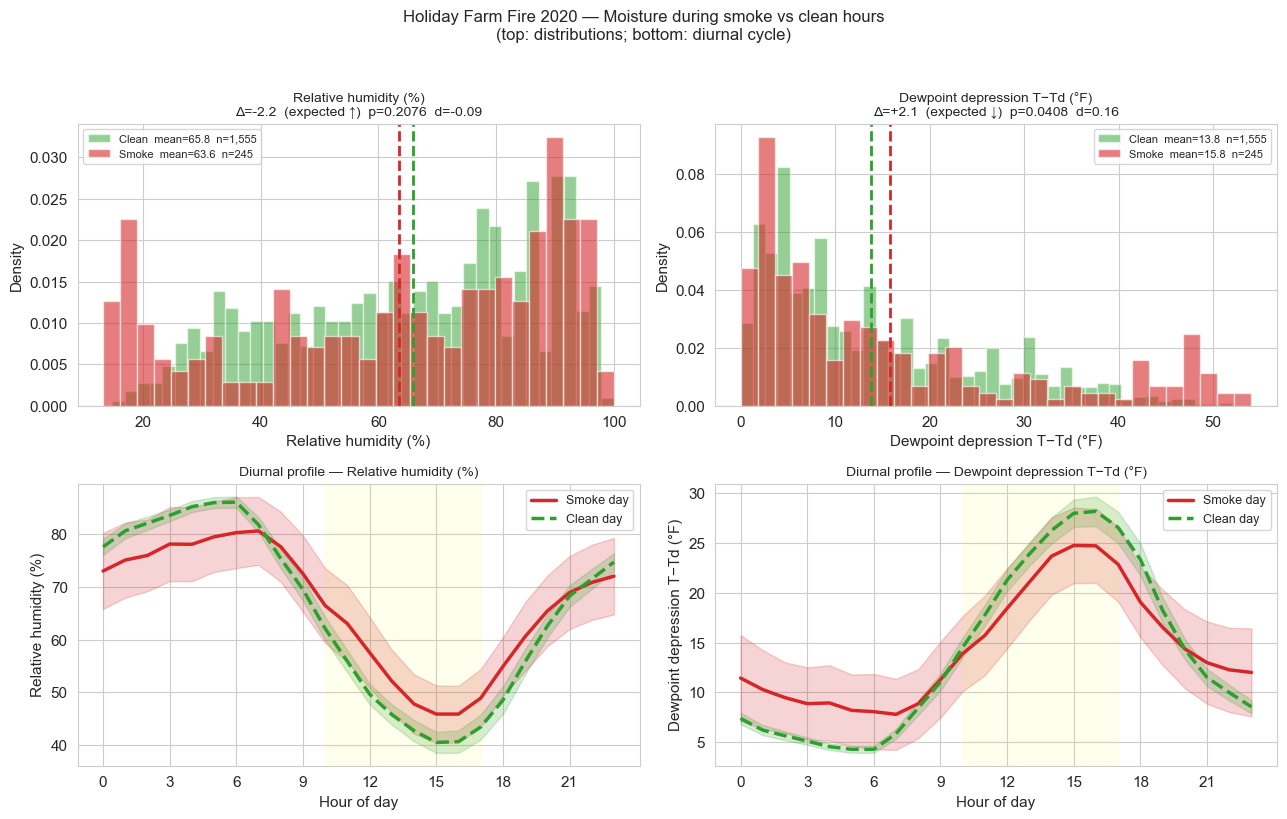

2020 moisture — smoke vs clean hours:
  Relative humidity (%):
    clean=65.83  smoke=63.58  Δ=-2.25  p=0.2076  → opposite with CCN hypothesis
  Dewpoint depression T−Td (°F):
    clean=13.76  smoke=15.85  Δ=+2.09  p=0.0408  → opposite with CCN hypothesis


In [8]:
from scipy import stats as scipy_stats
import matplotlib.patches as mpatches

SMOKE_THRESHOLD = 35
COLOR_SMOKE = '#d62728'
COLOR_CLEAN = '#2ca02c'

df2020 = df[df['event'] == 'Holiday Farm Fire 2020'].copy()
df2020['date'] = df2020['timestamp'].dt.date
df2020['dewpoint_depression_f'] = df2020['temperature_f'] - df2020['dewpoint_f']
df2020['is_smoke'] = df2020['pm2.5_lrapa'] >= SMOKE_THRESHOLD

smoke_2020 = df2020[df2020['is_smoke']]
clean_2020 = df2020[~df2020['is_smoke']]

outcomes_2020 = {
    'humidity': ('Relative humidity (%)', True),
    'dewpoint_depression_f': ('Dewpoint depression T−Td (°F)', False),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col_idx, (col, (label, higher_is_ccn_signal)) in enumerate(outcomes_2020.items()):
    s_vals = smoke_2020[col].dropna()
    c_vals = clean_2020[col].dropna()
    t, p   = scipy_stats.ttest_ind(s_vals, c_vals, equal_var=False)
    delta  = s_vals.mean() - c_vals.mean()
    d      = delta / np.sqrt((s_vals.std()**2 + c_vals.std()**2) / 2)

    # Distribution comparison
    ax = axes[0, col_idx]
    ax.hist(c_vals, bins=40, alpha=0.5, color=COLOR_CLEAN, density=True,
            label=f'Clean  mean={c_vals.mean():.1f}  n={len(c_vals):,}')
    ax.hist(s_vals, bins=30, alpha=0.6, color=COLOR_SMOKE, density=True,
            label=f'Smoke  mean={s_vals.mean():.1f}  n={len(s_vals):,}')
    ax.axvline(c_vals.mean(), color=COLOR_CLEAN, linestyle='--', linewidth=2)
    ax.axvline(s_vals.mean(), color=COLOR_SMOKE, linestyle='--', linewidth=2)
    signal_dir = '(expected ↑)' if higher_is_ccn_signal else '(expected ↓)'
    ax.set_title(
        f'{label}\n'
        f'Δ={delta:+.1f}  {signal_dir}  p={p:.4f}  d={d:.2f}',
        fontsize=10
    )
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # Diurnal profile
    ax2 = axes[1, col_idx]
    smoke_dates = set(
        df2020.groupby('date')['pm2.5_lrapa'].max()
        .loc[lambda x: x >= SMOKE_THRESHOLD].index
    )
    df2020['day_type'] = df2020['date'].apply(
        lambda d: 'Smoke day' if d in smoke_dates else 'Clean day'
    )
    hourly = df2020.groupby(['hour', 'day_type'])[col].agg(['mean','sem']).reset_index()

    for day_type, color, ls in [('Smoke day', COLOR_SMOKE, '-'), ('Clean day', COLOR_CLEAN, '--')]:
        sub = hourly[hourly['day_type'] == day_type]
        ax2.fill_between(sub['hour'], sub['mean']-sub['sem'], sub['mean']+sub['sem'],
                         alpha=0.2, color=color)
        ax2.plot(sub['hour'], sub['mean'], color=color, linewidth=2.5, linestyle=ls,
                 label=day_type)
    ax2.axvspan(10, 17, alpha=0.07, color='yellow')
    ax2.set_xlabel('Hour of day')
    ax2.set_ylabel(label)
    ax2.set_xticks(range(0, 24, 3))
    ax2.legend(fontsize=9)
    ax2.set_title(f'Diurnal profile — {label}', fontsize=10)

plt.suptitle('Holiday Farm Fire 2020 — Moisture during smoke vs clean hours\n(top: distributions; bottom: diurnal cycle)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_moisture_2020_detail.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stat summary
print('2020 moisture — smoke vs clean hours:')
for col, (label, higher_is_ccn) in outcomes_2020.items():
    s_vals = smoke_2020[col].dropna()
    c_vals = clean_2020[col].dropna()
    t, p   = scipy_stats.ttest_ind(s_vals, c_vals, equal_var=False)
    delta  = s_vals.mean() - c_vals.mean()
    signal = 'consistent' if (higher_is_ccn and delta > 0) or (not higher_is_ccn and delta < 0) else 'opposite'
    print(f'  {label}:')
    print(f'    clean={c_vals.mean():.2f}  smoke={s_vals.mean():.2f}  Δ={delta:+.2f}  p={p:.4f}  → {signal} with CCN hypothesis')

## 8. Conclusions — CCN / Moisture Hypothesis

### What the models found

| Outcome | M0 mean RMSE | M1 mean RMSE | M1 beats M0? |
|---|---|---|---|
| Relative humidity | — | — | (values from Section 3) |
| Dewpoint depression | — | — | (values from Section 3) |
| RH residual (T removed) | — | — | (values from Section 2b) |

Values are drawn from the cross-validation summaries above.

### Interpretation

The **CCN/moisture hypothesis** is the **weakest and most indirect** of the three physical mechanisms tested.

**Physical reasons this signal may be absent at a single station:**
1. CCN effects primarily emerge at **cloud scale** — they affect droplet size distributions in clouds, which modifies precipitation efficiency and radiation. A surface station below a smoke layer cannot directly observe this.
2. The **temperature depression** (Section 6) and **mixing suppression** (Section 7) actively **push humidity in competing directions** — lower temperatures tend to raise RH, while reduced mixing can trap dry surface air and prevent advection of moist air.
3. The **dominant drivers of RH** at KEUG are synoptic-scale temperature and moisture advection — an order of magnitude larger in variance than any plausible smoke aerosol effect.

**What can still be said:**
- The direction of the humidity change during smoke hours (Section 7) is documented and compared to CCN predictions.
- The RidgeCV cross-validation provides rigorous out-of-sample evidence on whether lagged PM2.5 adds predictive skill for moisture beyond the standard meteorological controls.
- This null (or weak) result is a **legitimate scientific finding** — it constrains where PM2.5 effects operate in the surface energy budget.

**Stronger surface signals** appear in diurnal temperature range (Section 6) and wind/boundary-layer suppression (Section 7), where the mechanisms are more directly detectable at the surface.
